In [72]:
import geopandas
import pandas as pd
from rasterio.warp import transform
from rasterio.crs import CRS
import xarray as xr
import rioxarray as rx
from osgeo import gdal, osr, gdal_array, ogr, gdalconst
import numpy as np
from matplotlib import pyplot as plt
from rasterio.crs import CRS
from skimage.measure import label, regionprops, regionprops_table

In [70]:
import cv2

def calc_sizes(floe=None, raster=None, plot_object=False, area_th_km2=1000):
    ''' Calculate region properties based on segmentation result
        Input:  floe - segmented object mask (2D binary matrix of 0/1)
                lons - 2D matrix with lons
                lats - 2D matrix with lats
                area_th_km2 - threshold of floe area to count it as a floe
                
        Output: Pandas data frame containing the following characteristics:
                'lon' (center coordinate),
                'lat' (center coordinate),
                'perimeter', # km
                'orientation' (azimuthal),
                'axis_major_length', # km
                'axis_minor_length'  # km
    '''
    
    floe = floe.astype(int)

    # Check if at least one pixel in original image is not 0
    if len(raster.data.shape)>2:
        img_data = raster.data[0][floe>0]
    else:
        img_data = raster.data[floe>0]
        
    props = regionprops_table(floe,
                              properties=('centroid',
                                          'area',
                                          'perimeter',
                                          'orientation',
                                          'axis_major_length',
                                          'axis_minor_length'),)

    # Get pixel size
    gt = np.array([float(x) for x in raster.coords['spatial_ref'].GeoTransform.split()])
    px_size = (gt[1]-gt[5]) / 2
    
    # Extract logitude form original raster
    ilon = raster.attrs['lat'][1][int(props['centroid-0']), int(props['centroid-1'])]
    props['lat'] = '{:.6f}'.format(ilon)
    
    # Extract latitude form original raster
    ilat = raster.attrs['lon'][1][int(props['centroid-0']), int(props['centroid-1'])]
    props['lon'] = '{:.6f}'.format(ilat)

    # Area in km2, the others are in km
    a = float(props['area']*px_size**2)*10**(-6)

    # Floe aspect ratio
    # 1.6-1.9 [Toyota et al, 2011], currently set to 4
    floe_aspect_ratio = props['axis_major_length'] / props['axis_minor_length']

    if (a<area_th_km2 and floe_aspect_ratio>=1 and floe_aspect_ratio<=4):
        props['area'] = float('{:.2f}'.format(a))
        orientation = float(np.rad2deg(props['orientation'])) % 360.
        props['orientation'] = '{:.0f}'.format(orientation)
        perimeter = float(props['perimeter']*px_size) / 1000.
        props['perimeter'] = '{:.2f}'.format(perimeter)
        maj_len = float(props['axis_major_length']*px_size) / 1000.
        props['axis_major_length'] = '{:.2f}'.format(maj_len)
        min_len = float(props['axis_minor_length']*px_size) / 1000.
        props['axis_minor_length'] = '{:.2f}'.format(min_len)
        #props['id'] = num_object

        if plot_object:
            os.makedirs(f'{HOME}/output/', exist_ok=True)
            plt.clf()
            fig, ax = plt.subplots()
            ax.imshow(floe, alpha=1, cmap='gray')
            plt.savefig(f'{HOME}/output/{num_object}_floe.png', bbox_inches='tight', dpi=120)
        else:
            pass

        props = pd.DataFrame(props)
        
        # Drop column with centroid coordiantes
        props = props.drop(['centroid-0', 'centroid-1'], axis=1)
        
        return props
    else:
        return None

In [31]:
def get_raster_lat_lon(img_path):
    ''' Get 2D lon lat matrices for raster as rioxarray object '''
    
    # Read the data
    da = rx.open_rasterio(img_path)

    # Compute the lon/lat coordinates with rasterio.warp.transform
    ny, nx = len(da['y']), len(da['x'])
    x, y = np.meshgrid(da['x'], da['y'])
    
    # Transform coordinates from local coordinate system
    # !TODO: {self.ras_epsg}
    
    raster_wkt = da.spatial_ref.crs_wkt
    tgt_wkt = '+proj=longlat +datum=WGS84 +no_defs +type=crs'

    lat, lon = transform(CRS.from_wkt(raster_wkt),
                         CRS.from_proj4(tgt_wkt),
                         x.flatten(),
                         y.flatten())
    
    lon = np.asarray(lon).reshape((ny, nx))
    lat = np.asarray(lat).reshape((ny, nx))
    da.attrs['lon'] = (('y', 'x'), lon)
    da.attrs['lat'] = (('y', 'x'), lat)
    return da.rio.reproject(CRS.from_proj4('+proj=stere +lat_0=90 +lat_ts=70 +lon_0=-45 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs +type=crs'))

In [32]:
# Open and process raster
img_path = '/mnt/denis/data/SAM_tests/tiff/UPS_proj_S1A_EW_GRDM_1SDH_20240605T040339_20240605T040443_054183_0696E4_DA21.tiff'
raster = get_raster_lat_lon(img_path)

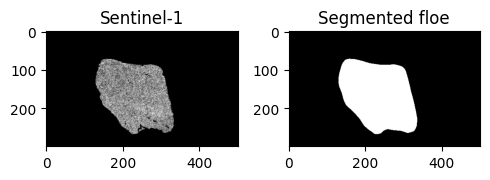

In [86]:
floe = gdal.Open('/mnt/denis/test_floe.tiff').ReadAsArray()

img_copy = raster.data[0].copy()
img_copy[floe<1] = 0

# Plot data
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 3))
xx1, xx2, yy1, yy2 = 5700, 6000, 3500, 4000 
axes[0].imshow(img_copy[xx1:xx2, yy1:yy2], cmap='gray')
axes[0].set_title('Sentinel-1')
axes[1].imshow(floe[xx1:xx2, yy1:yy2], cmap='gray')
axes[1].set_title('Segmented floe')
fig.tight_layout()

# Calculate sizes
res = calc_sizes(floe=floe, raster=raster, plot_object=False)

In [74]:
# Print floe sizes
res

,area,perimeter,orientation,axis_major_length,axis_minor_length,lat,lon
0,191.88,56.20,49,19.00,13.19,42.278322,79.160227
